In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("gurgaon_properties_missing_value_imputation.csv")

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss the leaf,sector 85,1.07,6524.0,2,2,3,21.0,Relatively New,1439.0,0,0,0,1,0,0,67
1,flat,la vida by tata housing,sector 113,2.78,11346.0,3,3,3,3.0,New Property,2599.0,1,1,0,0,0,0,174
2,flat,whiteland the aspen,sector 76,3.50,11917.0,3,4,3,8.0,Under Construction,2937.0,0,0,0,0,0,0,0
3,flat,sanskriti apartments,sector 43,2.50,13513.0,3,2,3,5.0,Old Property,1623.0,1,0,0,0,0,0,0
4,flat,tulip violet,sector 69,1.42,8998.0,3,3,2,8.0,Relatively New,1384.0,0,0,0,1,0,2,94


In [4]:
df.drop(columns=['society','price_per_sqft'],inplace=True)

In [5]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 85,1.07,2,2,3,21.0,Relatively New,1439.0,0,0,0,1,0,0,67
1,flat,sector 113,2.78,3,3,3,3.0,New Property,2599.0,1,1,0,0,0,0,174
2,flat,sector 76,3.50,3,4,3,8.0,Under Construction,2937.0,0,0,0,0,0,0,0
3,flat,sector 43,2.50,3,2,3,5.0,Old Property,1623.0,1,0,0,0,0,0,0
4,flat,sector 69,1.42,3,3,2,8.0,Relatively New,1384.0,0,0,0,1,0,2,94


In [6]:
df.shape

(3534, 16)

In [7]:
df.isnull().sum()

property_type      0
sector             0
price              0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(121)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(3413, 16)

# Luxury Score

<Axes: ylabel='luxury_score'>

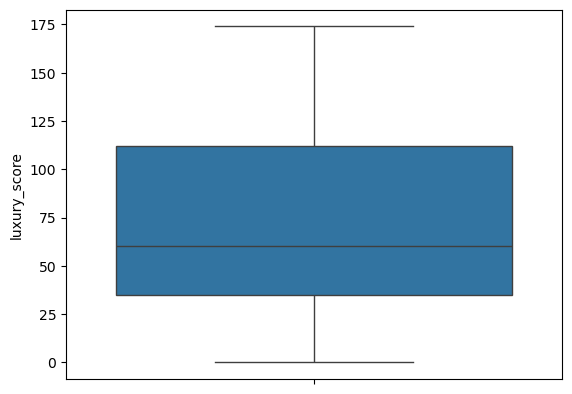

In [12]:
sns.boxplot(df['luxury_score'])

In [13]:
def categorize_luxury(score):
    if 0<=score<50:
        return "Low"
    elif 50<=score<150:
        return "Medium"
    elif 150<=score<175:
        return "High"
    else:
        return None

In [14]:
df['luxury_category']=df['luxury_score'].apply(categorize_luxury)

In [15]:
df['luxury_category'].value_counts()

luxury_category
Low       1512
Medium    1410
High       491
Name: count, dtype: int64

# floor num

In [16]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 85,1.07,2,2,3,21.0,Relatively New,1439.0,0,0,0,1,0,0,67,Medium
1,flat,sector 113,2.78,3,3,3,3.0,New Property,2599.0,1,1,0,0,0,0,174,High
2,flat,sector 76,3.50,3,4,3,8.0,Under Construction,2937.0,0,0,0,0,0,0,0,Low
3,flat,sector 43,2.50,3,2,3,5.0,Old Property,1623.0,1,0,0,0,0,0,0,Low
4,flat,sector 69,1.42,3,3,2,8.0,Relatively New,1384.0,0,0,0,1,0,2,94,Medium


In [17]:
def categorize_floor(floor):
    if 0<=floor<=2:
        return "Low Floor"
    elif 3<=floor<=10:
        return "Mid Floor"
    elif 11<=floor<=51:
        return "High Floor"
    else:
        return None

In [18]:
df['floor_category']=df['floorNum'].apply(categorize_floor)

In [19]:
df['floor_category'].value_counts()

floor_category
Mid Floor     1722
Low Floor      900
High Floor     791
Name: count, dtype: int64

In [20]:
df.drop(columns=['luxury_score','floorNum'],inplace=True)

In [21]:
df.shape

(3413, 16)

In [22]:
# split the cetegorical and numeriacl columns

In [23]:
categorical_cols=df.select_dtypes(include=['object']).columns

In [24]:
categorical_cols

Index(['property_type', 'sector', 'balcony', 'agePossession',
       'luxury_category', 'floor_category'],
      dtype='object')

In [25]:
numerical_cols=df.select_dtypes(include=['number']).columns

In [26]:
numerical_cols

Index(['price', 'bedRoom', 'bathroom', 'built_up_area', 'study room',
       'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type'],
      dtype='object')

In [27]:
# perform encoding

In [28]:
from sklearn.preprocessing import OrdinalEncoder
train_df=df.copy()

for col in categorical_cols:
    oe=OrdinalEncoder()
    train_df[col]=oe.fit_transform(train_df[[col]])
    print(oe.categories_)
    


[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [29]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,97.0,1.07,2,2,3.0,3.0,1439.0,0,0,0,1,0,0,2.0,0.0
1,0.0,17.0,2.78,3,3,3.0,1.0,2599.0,1,1,0,0,0,0,0.0,2.0
2,0.0,86.0,3.50,3,4,3.0,4.0,2937.0,0,0,0,0,0,0,1.0,2.0
3,0.0,50.0,2.50,3,2,3.0,2.0,1623.0,1,0,0,0,0,0,1.0,2.0
4,0.0,78.0,1.42,3,3,2.0,3.0,1384.0,0,0,0,1,0,2,2.0,2.0


In [30]:
# split data into training and testing parts
X=train_df.drop(columns=['price'],axis=1)
y=train_df['price']

# Method 1 - correlation analysis

<Axes: >

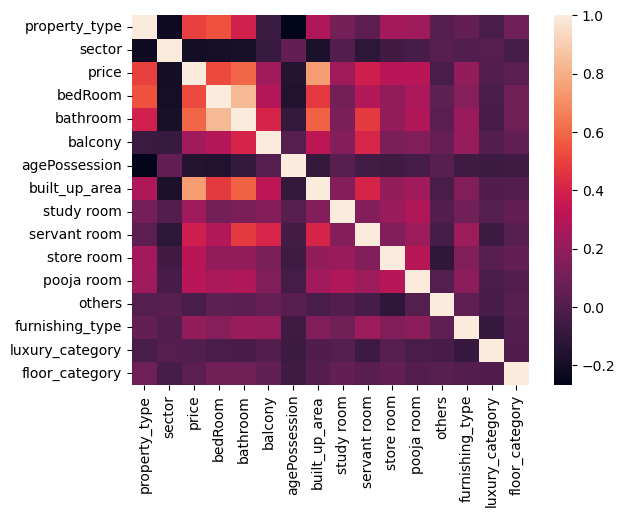

In [31]:
sns.heatmap(train_df.corr())

In [32]:
df1=train_df.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'features','price':'corr_score'})

In [33]:
df1

,features,corr_score
0,sector,-0.203952
1,price,1.000000
2,bedRoom,0.520377
3,bathroom,0.591347
4,balcony,0.241921
5,agePossession,-0.145862
6,built_up_area,0.744861
7,study room,0.230287
8,servant room,0.383260
9,store room,0.308500


# Method 2 - Random Forest Features Importance

In [34]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=100,random_state=42)
rfr.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
df2=pd.DataFrame({
    'features':X.columns,
    'rf-importance':rfr.feature_importances_
}).sort_values('rf-importance',ascending=False)

In [36]:
df2

,features,rf-importance
6,built_up_area,0.656248
1,sector,0.115067
0,property_type,0.088765
3,bathroom,0.022574
8,servant room,0.022324
2,bedRoom,0.017993
5,agePossession,0.014701
4,balcony,0.012581
7,study room,0.009895
9,store room,0.009271


# Method 3 - Gradient Boosting feature importances

In [37]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(X,y)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [38]:
df3=pd.DataFrame({
    'features':X.columns,
    'gb-importance':gbr.feature_importances_
}).sort_values('gb-importance',ascending=False)

In [39]:
df3

,features,gb-importance
6,built_up_area,0.692920
1,sector,0.113226
0,property_type,0.088236
3,bathroom,0.031739
8,servant room,0.023675
2,bedRoom,0.016602
9,store room,0.010913
5,agePossession,0.007400
7,study room,0.005918
10,pooja room,0.003428


# Method 4 - Permutation Importances

In [40]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

rfr=RandomForestRegressor(n_estimators=100,random_state=42)
rfr.fit(x_train,y_train)

per_imp=permutation_importance(rfr,x_test,y_test,n_repeats=30,random_state=42)

In [41]:
df4=pd.DataFrame({
    'features':X.columns,
    'pr-importance':per_imp.importances_mean
}).sort_values('pr-importance',ascending=False)

In [42]:
df4

,features,pr-importance
6,built_up_area,0.744482
0,property_type,0.155867
1,sector,0.148036
7,study room,0.006389
13,luxury_category,0.005330
4,balcony,0.005312
8,servant room,0.004672
12,furnishing_type,0.002322
14,floor_category,0.001296
2,bedRoom,-0.000281


# Method 5 - Lasso

In [43]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

ls=Lasso(alpha=0.1,random_state=42)
ls.fit(X_scaled,y)

df5=pd.DataFrame({
    'features':X.columns,
    'Lasso_coef':ls.coef_
}).sort_values('Lasso_coef',ascending=False)

In [44]:
df5

,features,Lasso_coef
6,built_up_area,1.404933
0,property_type,0.626347
3,bathroom,0.260190
9,store room,0.158794
8,servant room,0.117838
7,study room,0.114093
12,furnishing_type,0.051358
10,pooja room,0.029497
1,sector,-0.000000
2,bedRoom,0.000000


# Method 6 - RFE

In [45]:
from sklearn.feature_selection import RFE
estimator=RandomForestRegressor()

selector=RFE(estimator,n_features_to_select=X.shape[1],step=1)
selector=selector.fit(X,y)

selected_features=X.columns[selector.support_]
selected_coef=selector.estimator_.feature_importances_

In [46]:
df6=pd.DataFrame({
    'features':selected_features,
    'rf-score':selected_coef
}).sort_values('rf-score',ascending=False)

In [47]:
df6

,features,rf-score
6,built_up_area,0.663362
1,sector,0.111750
0,property_type,0.083493
3,bathroom,0.021945
8,servant room,0.020933
2,bedRoom,0.020394
5,agePossession,0.015483
4,balcony,0.013391
9,store room,0.010871
7,study room,0.008039


# Method 7-Linear Regression Weights

In [48]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

lr.fit(X_scaled,y)

df7 = pd.DataFrame({
    'features':X.columns,
    'lr_coef':lr.coef_
}).sort_values('lr_coef',ascending=False)

In [49]:
df7

,features,lr_coef
6,built_up_area,1.427783
0,property_type,0.713203
3,bathroom,0.441653
9,store room,0.197901
7,study room,0.176589
8,servant room,0.157123
12,furnishing_type,0.125041
10,pooja room,0.065321
13,luxury_category,0.052684
11,others,-0.012644


In [55]:
new_df=df1.merge(df2,on='features').merge(df3,on='features').merge(df4,on='features').merge(df5,on='features').merge(df6,on='features').merge(df7,on='features').set_index('features')

In [56]:
new_df

,corr_score,rf-importance,gb-importance,pr-importance,Lasso_coef,rf-score,lr_coef
features,,,,,,,
sector,-0.203952,0.115067,0.113226,0.148036,-0.000000,0.111750,-0.062913
bedRoom,0.520377,0.017993,0.016602,-0.000281,0.000000,0.020394,-0.215597
bathroom,0.591347,0.022574,0.031739,-0.003510,0.260190,0.021945,0.441653
balcony,0.241921,0.012581,0.002331,0.005312,0.000000,0.013391,-0.049370
agePossession,-0.145862,0.014701,0.007400,-0.004814,-0.000000,0.015483,-0.025166
built_up_area,0.744861,0.656248,0.692920,0.744482,1.404933,0.663362,1.427783
study room,0.230287,0.009895,0.005918,0.006389,0.114093,0.008039,0.176589
servant room,0.383260,0.022324,0.023675,0.004672,0.117838,0.020933,0.157123
store room,0.308500,0.009271,0.010913,-0.000298,0.158794,0.010871,0.197901


In [57]:
#normlize the score
new_df=new_df.divide(new_df.sum(axis=0),axis=1)

In [58]:
new_df

,corr_score,rf-importance,gb-importance,pr-importance,Lasso_coef,rf-score,lr_coef
features,,,,,,,
sector,-0.063809,0.126276,0.124183,0.163544,-0.000000,0.121931,-0.027963
bedRoom,0.162807,0.019745,0.018209,-0.000310,0.000000,0.022252,-0.095826
bathroom,0.185011,0.024773,0.034811,-0.003878,0.121772,0.023944,0.196302
balcony,0.075688,0.013806,0.002557,0.005868,0.000000,0.014611,-0.021944
agePossession,-0.045635,0.016133,0.008116,-0.005318,-0.000000,0.016893,-0.011185
built_up_area,0.233039,0.720174,0.759977,0.822473,0.657524,0.723794,0.634607
study room,0.072048,0.010859,0.006491,0.007058,0.053397,0.008771,0.078489
servant room,0.119908,0.024499,0.025967,0.005161,0.055149,0.022840,0.069837
store room,0.096518,0.010174,0.011969,-0.000330,0.074317,0.011861,0.087961


In [59]:
new_df[['corr_score','rf-importance','gb-importance','pr-importance','rf-score','lr_coef']].mean(axis=1).sort_values(ascending=False)

features
built_up_area      0.649011
bathroom           0.076827
sector             0.074027
servant room       0.044702
store room         0.036359
study room         0.030619
pooja room         0.023447
furnishing_type    0.022495
bedRoom            0.021146
balcony            0.015098
luxury_category    0.008615
floor_category     0.002396
others            -0.001243
agePossession     -0.003499
dtype: float64

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
rfr=RandomForestRegressor(n_estimators=100,random_state=42)
score=cross_val_score(rfr,X,y,cv=5,scoring='r2')
score.mean()

np.float64(0.8093376438161624)

In [63]:
scores=cross_val_score(rfr,X.drop(columns=['pooja room','study room','others']),y,cv=5,scoring='r2')
scores.mean()

np.float64(0.8073667374357141)

In [64]:
X=X.drop(columns=['pooja room','study room','others'])
y=df['price']

In [65]:
final_df=X
final_df['price']=y

In [66]:
final_df.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,97.0,2,2,3.0,3.0,1439.0,0,0,0,2.0,0.0,1.07
1,0.0,17.0,3,3,3.0,1.0,2599.0,1,0,0,0.0,2.0,2.78
2,0.0,86.0,3,4,3.0,4.0,2937.0,0,0,0,1.0,2.0,3.50
3,0.0,50.0,3,2,3.0,2.0,1623.0,0,0,0,1.0,2.0,2.50
4,0.0,78.0,3,3,2.0,3.0,1384.0,0,0,2,2.0,2.0,1.42


In [67]:
final_df.to_csv("gurgaon_properties_post_features_selection.csv",index=False)